3000 12
[0, 1]
2
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope']
2100
900
KNN report
               precision    recall  f1-score   support

           0       0.55      0.68      0.60       478
           1       0.50      0.37      0.42       422

    accuracy                           0.53       900
   macro avg       0.52      0.52      0.51       900
weighted avg       0.53      0.53      0.52       900


 KNN Accuracy: 53.1 %
KNN Precision: 52.4 %
KNN Recall: 52.2 %
KNN Confusion Matrix:
 [[323 155]
 [267 155]]
****************************************************************************************************
Naive report
               precision    recall  f1-score   support

           0       0.52      0.61      0.56       478
           1       0.45      0.37      0.41       422

    accuracy                           0.50       900
   macro avg       0.49      0.49      0.48       900
weighted avg       0.49      0.50      

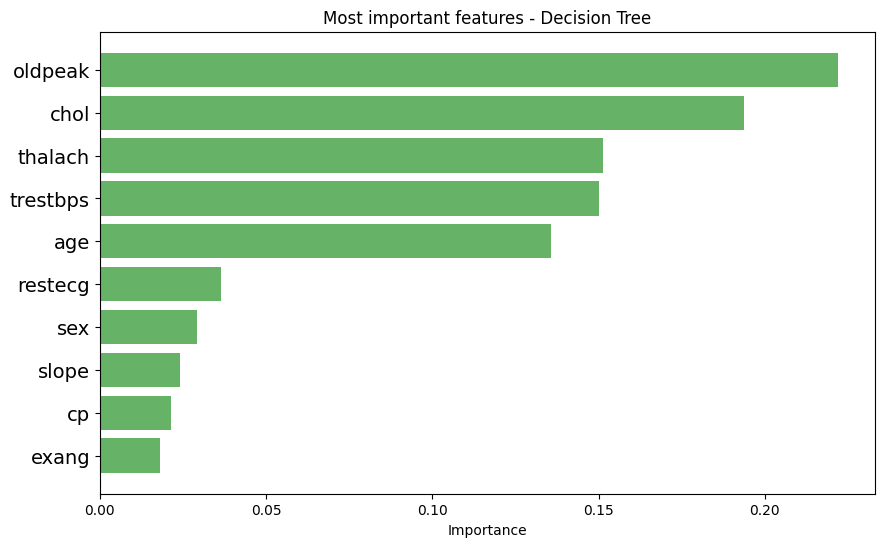

In [3]:

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn import tree
import pandas as pd
import numpy as np
import graphviz


# Load the CSV file into a pandas dataframe
def load_csv(file_path):
    df = pd.read_csv(file_path)
    return df


# Solve missing values
def solve_missing(df):
    imputer = SimpleImputer(strategy="median")
    df = imputer.fit_transform(df)
    return df


# Converting categorical Values to Numerical values
def label_encode_categorical_features(df):
    le = LabelEncoder()
    df = df.apply(le.fit_transform)
    return df


# Split data into training and testing
def split_data(features, goal, test_size=0.5, random_state=3):
    X_train, X_test, y_train, y_test = train_test_split(features, goal, test_size=test_size, random_state=random_state)
    return X_train, X_test, y_train, y_test


# Determine features and goal
def determine_features_and_goal(df, target="target"):
    features = df.drop(columns=[target])
    goal = df[target]
    return features, goal


# Apply KNN classifier
def apply_knn_classifier(K,X_train, X_test, y_train):
    knn = KNeighborsClassifier(n_neighbors=K)
    knn.fit(X_train, y_train)
    return knn.predict(X_test)


# Apply Naive Bayes classifier
def apply_naive_bayes_classifier(X_train, X_test, y_train):
    gnb = GaussianNB()
    gnb.fit(X_train, y_train)
    return gnb.predict(X_test)


# Apply decision tree classifier
def apply_decision_tree_classifier(X_train, X_test, y_train):
    dt = DecisionTreeClassifier()
    dt.fit(X_train, y_train)
    return dt.predict(X_test),dt


#Apply randomForest classifier
def apply_random_forest_classifier(X_train, X_test, y_train):
    rm = RandomForestClassifier(n_estimators = 100, max_depth=25, criterion = "gini", min_samples_split=10, random_state=42)
    rm.fit(X_train, y_train)
    rm_prd = rm.predict(X_test)
    return rm_prd,rm


# Calculate performance using confusion matrix
def calculate_performance(y_true, y_pred):
    accuracy = round(accuracy_score(y_true, y_pred) * 100 ,1)
    precision = round(precision_score(y_true, y_pred, average='macro') * 100 ,1)
    recall = round(recall_score(y_true, y_pred, average='macro') * 100 ,1)
    cm = confusion_matrix(y_true, y_pred)
    return accuracy, precision, recall, cm


# Remove outliers using the IQR method
def remove_outliers(df, columns):
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filtering the outliers
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    return df






if __name__ == '__main__':
    file_path = "heart_failure.csv"
    df = load_csv(file_path)
    df=df.replace([np.inf, -np.inf], np.nan).dropna()

    x,y=df.shape
    print(x,y)

    # Remove outliers
    columns_to_check = ['age', 'thalach', 'trestbps']
    df = remove_outliers(df, columns_to_check)


    features, goal = determine_features_and_goal(df)
    target=goal.tolist()
    target= list(set(goal)) # you can also use unique(target) to get the unique values of the list
    class_names = [str(class_name) for class_name in target]
    print(target)
    print(len(target))

    # F Will contain the features names only
    F=list(features)
    print(F)


    # First Step: call function solve_missing to solve missing values
    df = label_encode_categorical_features(df)
    df = solve_missing(df)

    # Step 2: Split Data into training and testing sets

    X_train, X_test, y_train, y_test = split_data(features, goal, test_size=0.3, random_state=13)
    X_train = label_encode_categorical_features(X_train)
    X_test = label_encode_categorical_features(X_test)
    print(len(X_train))
    print(len(X_test))


    ##################################################################################################
    # Step3 : Apply first classifier  "KNN"
    # x =3000
    # len(X_train) = random based on training set
    K=round(np.sqrt(len(X_train)))
    y_pred_knn = apply_knn_classifier(K,X_train, X_test, y_train)

    # Step3.1 : Calculate the performance of first classifier  "KNN" and print results
    accuracy_knn, precision_knn, recall_knn, cm_knn=calculate_performance(y_test,y_pred_knn)
    print("KNN report\n",classification_report(y_test, y_pred_knn, target_names=class_names))
    print("\n KNN Accuracy:",accuracy_knn,'%')
    print("KNN Precision:",precision_knn,'%')
    print("KNN Recall:",recall_knn,'%')
    print("KNN Confusion Matrix:\n",cm_knn)
    print('*'*100)
    #################################################################################################


    # Step 4:  Apply second classifier  "Naive Bayes"
    y_pred_nb = apply_naive_bayes_classifier(X_train, X_test, y_train)

    # Step 4.1: Calculate the performance of second classifier  "Naive Bayes" and print results
    accuracy_nb, precision_nb, recall_nb, cm_nb=calculate_performance(y_test, y_pred_nb)
    print("Naive report\n",classification_report(y_test, y_pred_nb, target_names=class_names))
    print("\n NaiveBayes Accuracy: ",accuracy_nb,'%')
    print("NaiveBayes Precision:",precision_nb,'%')
    print("NaiveBayes Recall:",recall_nb,'%')
    print("Naive Confusion Matrix:\n",cm_nb)
    print('*'*100)

    #################################################################################################


    # Step 5: Apply the third classifier  "Decision tree"
    y_pred_dt,dt = apply_decision_tree_classifier(X_train, X_test, y_train)

    # Step 5.1: Calculate the performance of the third classifier  "Decision tree" and print results
    accuracy_dt, precision_dt, recall_dt, cm_dt=calculate_performance(y_test, y_pred_dt)
    print("DT report\n",classification_report(y_test, y_pred_dt, target_names=class_names))
    print("\n Decision Tree Accuracy: ",accuracy_dt,'%')
    print("Decision Tree Precision:",precision_dt,'%')
    print("Decision Tree Recall:",recall_dt,'%')
    print("DT Confusion Matrix:\n",cm_dt)
    print('*'*100)


    #################################################################################################


    # Step 6: Apply the classifier  "ٌRandom Forest Classifier"
    y_pred_rf, rf = apply_random_forest_classifier(X_train, X_test, y_train)

    # Step 6.1: Calculate the performance of the Random Forest classifier and print results
    accuracy_rf, precision_rf, recall_rf, cm_rf = calculate_performance(y_test, y_pred_rf)
    print("Random Forest report\n", classification_report(y_test, y_pred_rf, target_names=class_names))
    print("\n Random Forest Accuracy: ", accuracy_rf, '%')
    print("Random Forest Precision:", precision_rf, '%')
    print("Random Forest Recall:", recall_rf, '%')
    print("Random Forest Confusion Matrix:\n", cm_rf)
    print('*'*100)


    # Use this code to draw the decision tree and save it in tree.png

    # Assuming you have a decision tree model 'dt', feature names 'F', and target class names 'target'
    dot_data = tree.export_graphviz(
        dt,
        feature_names=F,
        class_names=class_names,
        filled=True,
        rounded=True,
        special_characters=True,
        out_file=None,
    )

    graph = graphviz.Source(dot_data)
    graph.format = "png"
    graph.render("Tree")  # Save the visualization to a file named "Tree.png"




    # Create list of top most features based on importance using information gain from Decision tree
    feature_names = X_train.columns
    feature_imports = dt.feature_importances_
    most_imp_features = pd.DataFrame([f for f in zip(feature_names,feature_imports)], columns=["Feature", "Importance"]).nlargest(10, "Importance")
    most_imp_features.sort_values(by="Importance", inplace=True)
    plt.figure(figsize=(10,6))
    plt.barh(range(len(most_imp_features)), most_imp_features.Importance, align='center', alpha=0.6,color="green")
    plt.yticks(range(len(most_imp_features)), most_imp_features.Feature, fontsize=14)
    plt.xlabel('Importance')
    plt.title('Most important features - Decision Tree')
    plt.show()